In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

with open('../outputs/classical/results.json') as f:
    rf = json.load(f)

print(rf)

{'elev_std': {'best_params': {'max_depth': 20, 'n_estimators': 200}, 'train_mae': 19.8554, 'train_rmse': 27.344, 'val_mae': 41.2931, 'val_rmse': 58.3944}, 'elev_mean': {'best_params': {'max_depth': 20, 'n_estimators': 200}, 'train_mae': 0.4513, 'train_rmse': 0.8047, 'val_mae': 0.5416, 'val_rmse': 1.1864}, 'slope_dir': {'best_params': {'max_depth': 20, 'n_estimators': 200}, 'train_mae': 26.5287, 'train_rmse': 32.1248, 'val_mae': 43.5922, 'val_rmse': 51.1042}}


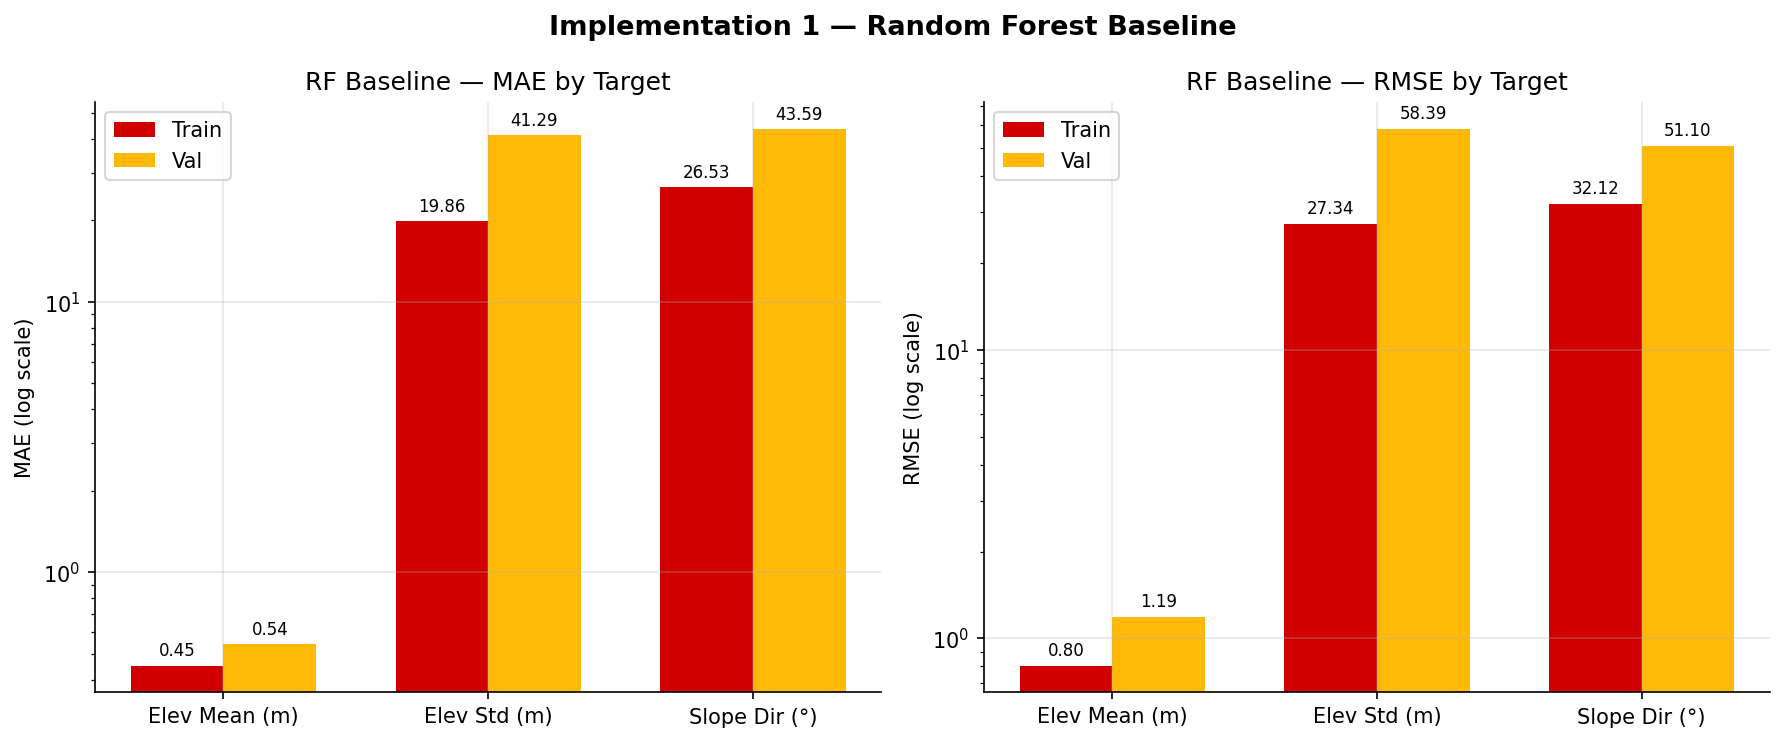

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

targets = ['elev_mean', 'elev_std', 'slope_dir']
labels  = ['Elev Mean (m)', 'Elev Std (m)', 'Slope Dir (°)']
x = np.arange(len(targets))
w = 0.35

for ax, metric in zip(axes, ['mae', 'rmse']):
    train_vals = [rf[t][f'train_{metric}'] for t in targets]
    val_vals   = [rf[t][f'val_{metric}']   for t in targets]
    
    bars_train = ax.bar(x - w/2, train_vals, w, label='Train', color='#d00000')
    bars_val   = ax.bar(x + w/2, val_vals,   w, label='Val',   color='#ffba08')
    
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(metric.upper() + ' (log scale)')
    ax.set_title(f'RF Baseline — {metric.upper()} by Target')
    ax.legend()
    
    for bar in bars_train:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    for bar in bars_val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Implementation 1 — Random Forest Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

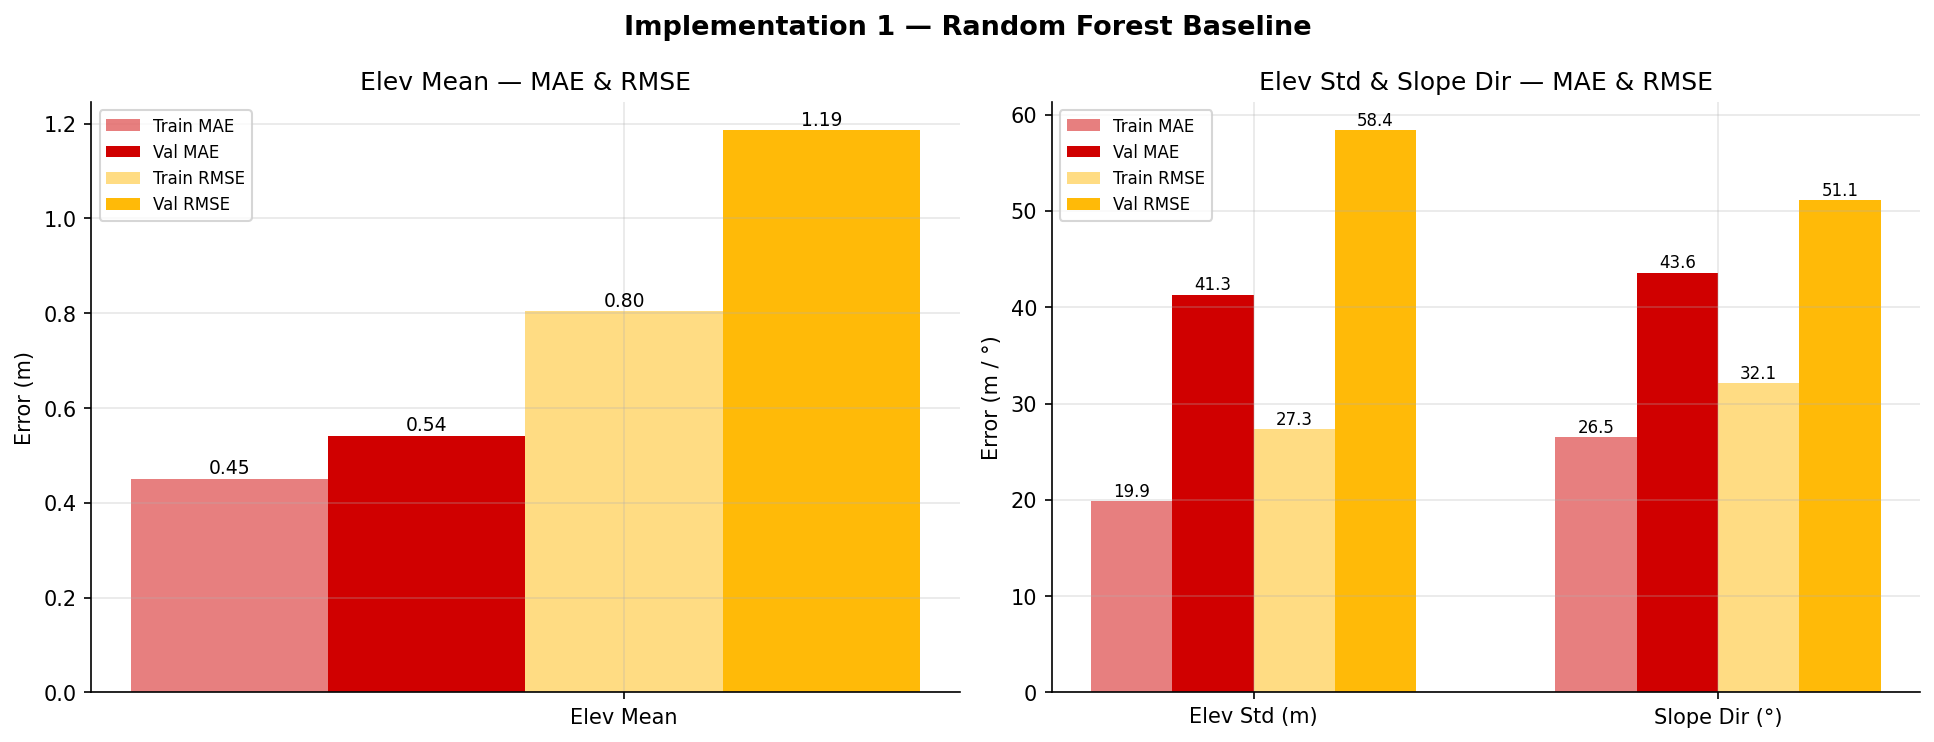

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: elev_mean alone (sub-meter scale)
ax = axes[0]
targets_left = ['elev_mean']
labels_left  = ['Elev Mean']
x = np.arange(len(targets_left))
w = 0.35

for metric, color in zip(['mae', 'rmse'], ['#d00000', '#ffba08']):
    train_val = rf['elev_mean'][f'train_{metric}']
    val_val   = rf['elev_mean'][f'val_{metric}']
    offset = -w/2 if metric == 'mae' else w/2
    b1 = ax.bar(0 + offset - w/2, train_val, w/2, label=f'Train {metric.upper()}', color=color, alpha=0.5)
    b2 = ax.bar(0 + offset,       val_val,   w/2, label=f'Val {metric.upper()}',   color=color)
    ax.text(b1.patches[0].get_x() + b1.patches[0].get_width()/2, train_val + 0.01,
            f'{train_val:.2f}', ha='center', fontsize=9)
    ax.text(b2.patches[0].get_x() + b2.patches[0].get_width()/2, val_val + 0.01,
            f'{val_val:.2f}', ha='center', fontsize=9)

ax.set_xticks([0]); ax.set_xticklabels(['Elev Mean'])
ax.set_ylabel('Error (m)')
ax.set_title('Elev Mean — MAE & RMSE')
ax.legend(fontsize=8)

# Right: elev_std and slope_dir (tens of meters / degrees)
ax = axes[1]
targets_right = ['elev_std', 'slope_dir']
labels_right  = ['Elev Std (m)', 'Slope Dir (°)']
x = np.arange(len(targets_right))
w = 0.35

for metric, color in zip(['mae', 'rmse'], ['#d00000', '#ffba08']):
    train_vals = [rf[t][f'train_{metric}'] for t in targets_right]
    val_vals   = [rf[t][f'val_{metric}']   for t in targets_right]
    offset = -w/2 if metric == 'mae' else w/2
    bars_t = ax.bar(x + offset - w/4, train_vals, w/2, label=f'Train {metric.upper()}', color=color, alpha=0.5)
    bars_v = ax.bar(x + offset + w/4, val_vals,   w/2, label=f'Val {metric.upper()}',   color=color)
    for b, v in zip(bars_t, train_vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)
    for b, v in zip(bars_v, val_vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels_right)
ax.set_ylabel('Error (m / °)')
ax.set_title('Elev Std & Slope Dir — MAE & RMSE')
ax.legend(fontsize=8)

fig.suptitle('Implementation 1 — Random Forest Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
with open('../outputs/deeplearning/impl2/results.json') as f:
    impl2 = json.load(f)

print(f"Impl2 best val RMSE: {impl2['best_val_rmse']:.2f}m")

Impl2 best val RMSE: 74.38m


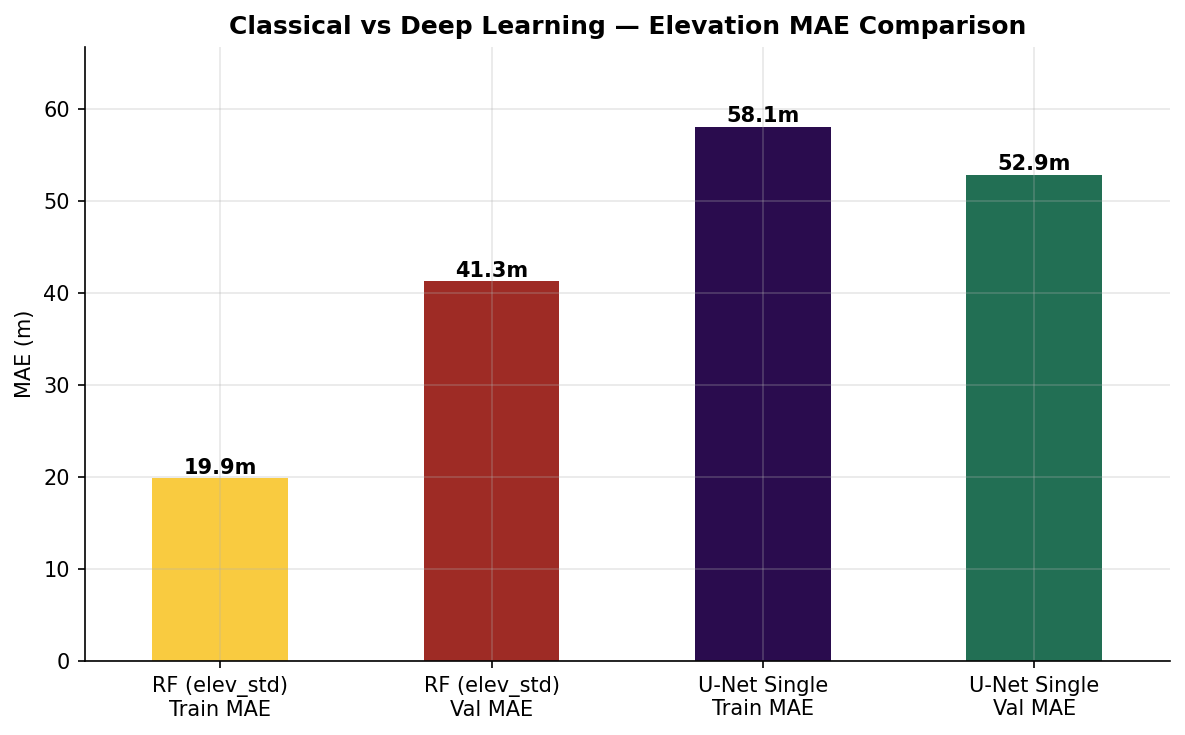

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

methods = ['RF (elev_std)\nTrain MAE', 'RF (elev_std)\nVal MAE', 'U-Net Single\nTrain MAE', 'U-Net Single\nVal MAE']
values  = [rf['elev_std']['train_mae'], rf['elev_std']['val_mae'],
           impl2['history']['train_loss'][-1], min(impl2['history']['val_mae'])]
colors  = ['#f9cb40', '#9e2b25', '#2a0c4e', '#226f54']
alphas  = [0.6, 1.0, 0.6, 1.0]

bars = ax.bar(methods, values, color=colors, width=0.5)
ax.set_xlim(-0.5, 3.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}m', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('MAE (m)')
ax.set_title('Classical vs Deep Learning — Elevation MAE Comparison', fontweight='bold')
ax.set_ylim(0, max(values) * 1.15)

plt.tight_layout()
plt.show()